In [1]:
"""
1. 查看pFind+pPred鉴定结果中的target PSM在.sa文件中的位置
    - 在.sa中q_value的分布
    - 在.sa中是topk的分布
"""
import os
from utils import *

In [20]:
"""
step1: meta info
    stage1_dir: 普通模式经过一轮重打分的结果(.qry.res)
    res_dir: DL模式的最终结果(.spectra)
"""
# stage1_dir = "D:/workspace/pFindWorkspace/Astral/top50-complete/result/"  # Astral
# res_dir = "D:/workspace/pFindWorkspace/Astral/top50-complete/result/dl-0628/"  # Astral

# stage1_dir = "D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/"  # HLA
# res_dir = "D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/dl-0628/"  # HLA

stage1_dir = "D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/"  # Gygi_2015_NBT
res_dir = "D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/dl-0628/"  # Gygi_2015_NBT
res_paths = [os.path.join(stage1_dir,filename) for filename in os.listdir(stage1_dir) if filename.endswith(".qry.res")]

In [21]:
def get_spec2topkres(res_paths,topk=None):
    if topk is None:
        topk = 1e6
    spec2res = dict()
    for res_path in res_paths:
        print(res_path)
        fr = open(res_path,"r")
        while True:
            line = fr.readline()
            if not line:
                break
            if line.startswith("S"):
                spectrum_name = fr.readline().strip()
                spec2res[spectrum_name] = list()
                res = spec2res[spectrum_name]
            else:
                items = line.strip().split("\t")
                rank = int(items[0])
                if rank<=topk:
                    mod_num = int(items[6])
                    mods = ""
                    for i in range(mod_num):
                        mods += f"{items[7+2*i]},{items[8+2*i]};"
                    modified_seq = items[1]+"\t"+mods
                    is_decoy = int(items[8+mod_num*2])
                    # raw_score = float(items[3])
                    fine_score = float(items[4])
                    res.append([modified_seq,is_decoy,fine_score])  # 从raw_score换成fine_score
        fr.close()
    return spec2res

In [22]:
"""
step2:
"""
spec2tp = dict()  # spectrum_name -> target PSM
fr = open(os.path.join(res_dir,"pFind.spectra"),"r")
next(fr,None)
for line in fr:
    items = line.strip().split("\t")
    q_value = float(items[4])
    if q_value > 0.01:
        break
    is_decoy = (items[15]=="decoy")
    if not is_decoy:
        spectrum_name = items[0]
        seq,mod = items[5],items[10]
        modified_seq = seq+"\t"+mod
        spec2tp[spectrum_name] = modified_seq
fr.close()


spec2res = get_spec2topkres(res_paths)
spec_res = [(spectrum_name,res) for spectrum_name,res in spec2res.items() if len(res)>0]
# spec_res来自qry.res，可以获取decoy信息，但它不是按照m_lfScore排序的，所以需要手动排序
for spectrum_name,res in spec_res:
    res = sorted(res,key=lambda item:item[2],reverse=False)  # 按重打分分数从小到大排序
    cur_score = -100
    cur_rank = 0
    for r in res:
        if cur_score!=r[2]:
            cur_rank += 1
            cur_score = r[2]
        r.append(cur_rank)
spec_res = sorted(spec_res, key=lambda item:item[1][0][2])  # reverse=True
q_values = list()
t,d = 1e-10,0.0
modified_seqs = set()
for spectrum_name,res in spec_res:
    modified_seq,is_decoy,_,_ = res[0]
    if modified_seq in modified_seqs or is_decoy==2:  # or is visible_decoy
        q_values.append(d/t)
        continue
    if is_decoy:
        d += 2.0
    else:
        t += 1.0
    q_values.append(d/t)
    modified_seqs.add(modified_seq)
min_q_value = 1e6
for i in range(len(q_values)-1,-1,-1):
    q_values[i] = min_q_value = min(q_values[i],min_q_value)


collections = list()
for i,(spectrum_name,res) in enumerate(spec_res):
    if spectrum_name not in spec2tp:
        continue
    target_modified_seq = spec2tp[spectrum_name]
    for modified_seq,is_decoy,_,rank in res:
        if modified_seq == target_modified_seq:
            collections.append((q_values[i],rank))
            break

D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F1.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F10.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F11.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F12.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F13.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F14.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F15.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F16.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F17.L1.qry.res
D:/workspace/pFindWorkspace/normal/Gygi_2025_NBT/restrict-new/result/restrict-new.F18.L1.qry.res
D:/workspace/pFindWorkspace/nor

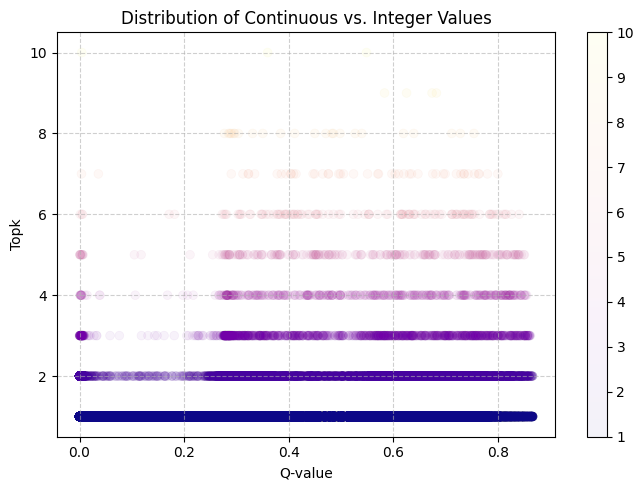

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# 提取数据
x_values = np.array([point[0] for point in collections])  # 连续值 [0,1]
y_values = np.array([point[1] for point in collections])  # 整数值 [1,10]

# 创建画布
plt.figure(figsize=(7, 5))

# 绘制散点图
# # 计算密度
# xy = np.vstack([x_values, y_values])
# z = gaussian_kde(xy)(xy)

# 按密度着色
scatter = plt.scatter(
    x=x_values,
    y=y_values,
    c=y_values,
    # c=z,                   # 使用密度值作为颜色映射
    cmap='plasma',         # 更适合表示密度的色卡
    alpha=0.05,
    s=40,
    # edgecolors='w',
    linewidths=0.5
)

# 添加颜色条和标签
cbar = plt.colorbar(scatter)
# cbar.set_label('Topk')

# 设置坐标轴和标题
plt.grid(True, linestyle='--', alpha=0.6)
plt.title('Distribution of Continuous vs. Integer Values')
plt.xlabel('Q-value')
plt.ylabel('Topk')
# plt.xlim(-0.05, 1.05)
plt.ylim(0.5, 10.5)

# # 添加每个类别的均值线
# for cat in range(1, 11):
#     cat_indices = np.where(y_values == cat)[0]
#     if len(cat_indices) > 0:
#         cat_mean = np.mean(x_values[cat_indices])
#         plt.axvline(x=cat_mean, ymin=(cat-0.5)/10, ymax=(cat+0.5)/10, 
#                     color='red', linestyle='--', alpha=0.7)
#         plt.text(cat_mean, cat, f'Mean: {cat_mean:.2f}', 
#                  va='center', ha='right', fontsize=8, color='red')

plt.tight_layout()
plt.show()

[0.9856608077676717, 0.011201123036878893, 0.0018951247331325126, 0.0006419442575965841, 0.0003348638610241862, 0.00015354019828619893, 6.87275173281081e-05, 3.36326148626912e-05, 5.849150410902816e-06, 4.386862808177112e-06]


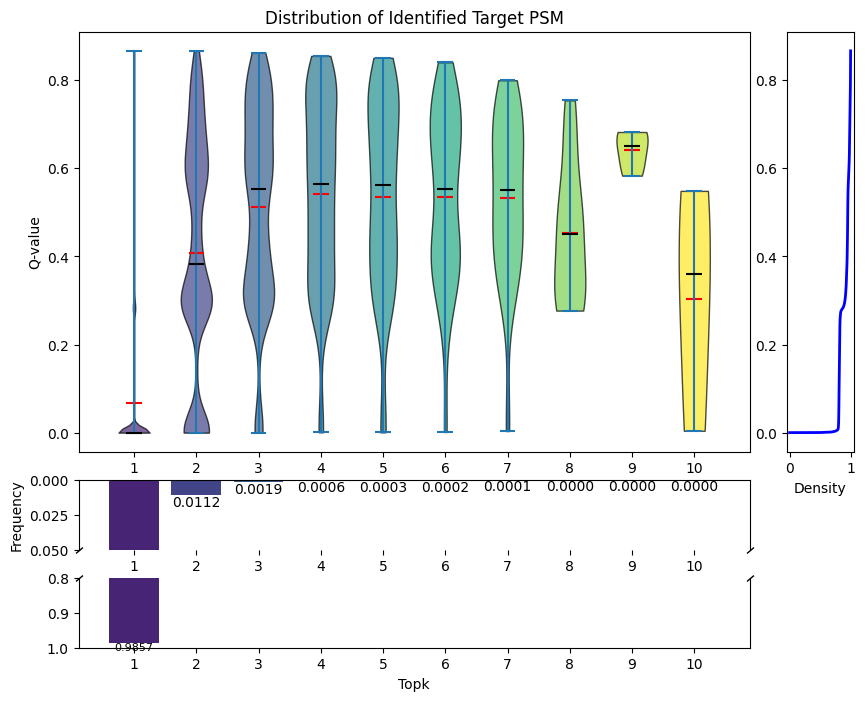

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from scipy.interpolate import make_interp_spline
from matplotlib.gridspec import GridSpec

def plot_cdf(values, plot_type="line", bins=50):
    if plot_type == "line":
        sorted_data = np.sort(np.array(values))
        n = len(sorted_data)
        cumulative_prob = np.arange(1,n+1)/n
        # 创建图表
        plt.plot(sorted_data, cumulative_prob, 'b-', linewidth=2)
    else:
        plt.hist(
            values, 
            bins=bins,
            range=(0, 1),
            density=True,
            cumulative=True,
            histtype='step',
            color='b',
            linewidth=2
        )


# 创建画布和GridSpec布局
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(3, 2, figure=fig, 
              height_ratios=[6, 1, 1], 
              width_ratios=[10, 1])

# 绘制左上角的小提琴图
ax1 = fig.add_subplot(gs[0, 0])
rank_num = 10
data_by_rank = [[] for i in range(rank_num)]
for q_value,rank in collections:
    data_by_rank[rank-1].append(q_value)
# 计算每个rank的数据量
sizes = [len(data) for data in data_by_rank]
total_size = sum(sizes)
sizes_ratio = [c/total_size for c in sizes]
print(sizes_ratio)
violin_parts = ax1.violinplot(
    data_by_rank,
    positions=range(1, 11),
    showmeans=True,
    showmedians=True,
    showextrema=True,
)
# 获取颜色映射
cmap = plt.cm.viridis
# 计算归一化的颜色值（基于小提琴的位置）
colors = [cmap(i/len(violin_parts['bodies'])) for i in range(1,len(violin_parts['bodies'])+1)]
# 为每个小提琴设置不同的颜色
for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_edgecolor('black')
    pc.set_alpha(0.7)  # 设置透明度
violin_parts['cmeans'].set_color('red')
violin_parts['cmedians'].set_color('black')
# 设置小提琴图的标题和y轴标签
ax1.set_title('Distribution of Identified Target PSM')
ax1.set_ylabel('Q-value')
# ax1.set_xlim(0.5, 10.5)
ax1.set_xticks(range(1, 11))


# 绘制左下角的图
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)  # 与ax1共享x轴
ax3 = fig.add_subplot(gs[2, 0], sharex=ax1)  # 与ax1共享x轴
ax2.bar(np.arange(1,11), np.array(sizes_ratio), color=colors)
ax3.bar(np.arange(1,11), np.array(sizes_ratio), color=colors)
ax2.set_ylim(0,0.05)
ax3.set_ylim(0.8,1)
ax2.invert_yaxis()  # 翻转y轴
ax3.invert_yaxis()  # 翻转y轴
#绘制断裂处的标记
d = .85  #设置倾斜度
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=5,
    linestyle='none', color='k', mec='k', mew=1, clip_on=False)
ax2.plot([0, 1], [0, 0], transform=ax2.transAxes, **kwargs)
ax3.plot([0, 1], [1, 1], transform=ax3.transAxes, **kwargs)
ax2.spines['bottom'].set_visible(False)  # 关闭子图2中底部脊
ax3.spines['top'].set_visible(False)  # 关闭子图1中顶部脊
# 设置柱状图的y轴标签和范围
ax2.set_ylabel('Frequency')
for i,c in enumerate(sizes_ratio):
    if i>0:
        ax2.text(i+1, c, f"{c:.4f}", ha='center', va='top', fontsize=10)
    else:
        ax3.text(i+1, c, f"{c:.4f}", ha='center', va='top', fontsize=8)


# 第二列子图（不与左边共享x轴）
ax4 = fig.add_subplot(gs[0, 1])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[2, 1])
plt.subplots_adjust(hspace=0.15, wspace=0.1)  # 减少子图之间的间距
# 绘制右上角的图
q_values = [point[0] for point in collections]
sorted_data = np.sort(np.array(q_values))
n = len(sorted_data)
cumulative_prob = np.arange(1,n+1)/n
# 创建图表
ax4.plot(cumulative_prob, sorted_data, 'b-', linewidth=2)


ax3.set_xlabel('Topk')
# ax3.set_ylim(0,1.2)
ax4.set_xlabel('Density')
ax5.axis('off')
ax6.axis('off')

# plt.tight_layout()
plt.show()

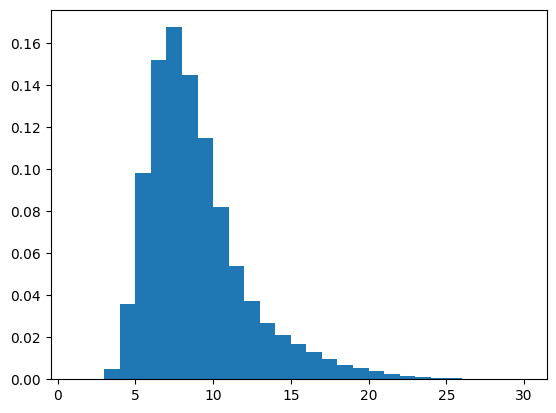

In [52]:
"""
2. 查看q_value<=0.01的target PSM细打分的分布
结论：细打分分数小于1的PSM不进行预测
"""
import math

raw_scores = list()
fr = open(os.path.join(res_dir, "pFind.spectra"),"r")
next(fr,None)
for line in fr:
    items = line.strip().split("\t")
    q_value = float(items[4])
    if q_value>0.01:
        break
    is_decoy = (items[15]=="decoy")
    if is_decoy:
        continue
    raw_score = float(items[8])
    raw_scores.append(raw_score)
fr.close()

raw_scores = np.array(raw_scores)
int_min = math.floor(np.min(raw_scores))
int_max = math.ceil(np.max(raw_scores))
plt.hist(raw_scores, bins=list(range(int_min,int_max+1)), density=True)
plt.show()

In [55]:
num = 0
for a in raw_scores:
    if a<=2:
        num += 1
print(num)

2


D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F1.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F10.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F11.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F12.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F2.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F3.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F4.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F5.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F6.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F7.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F8.L1.qry.res
D:/workspace/pFindWorkspace/HLA/C3N02671-new/result/C3N02671-new.F9.L1.qry.res


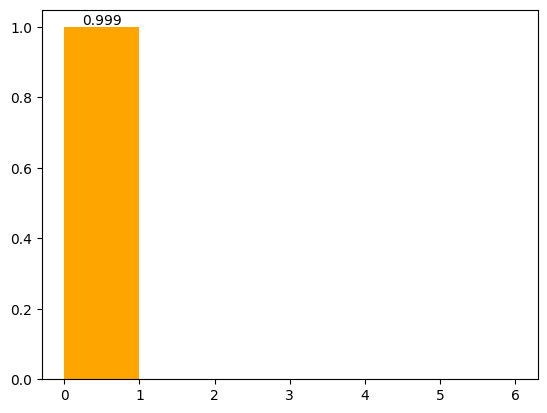

In [56]:
"""
3. 查看q_value<=0.01的target PSM细打分与该谱图最高分PSM之差的分布
结论：细打分分数小于1的PSM不进行预测
"""
import math

# 从pFind.spectra中读取q_value<=0.01的target PSM的raw_scores
spec2raw_score = dict()
fr = open(os.path.join(res_dir, "pFind.spectra"),"r")
next(fr,None)
for line in fr:
    items = line.strip().split("\t")
    q_value = float(items[4])
    if q_value>0.01:
        break
    is_decoy = (items[15]=="decoy")
    if is_decoy:
        continue
    spectrum_name = items[0]
    raw_score = float(items[8])
    spec2raw_score[spectrum_name] = raw_score
fr.close()

raw_scores_diff = list()
spectrum_name = None
for res_path in res_paths:
    print(res_path)
    fr = open(res_path, "r")
    while True:
        line = fr.readline()
        if not line:
            break
        if line.startswith("S"):
            if spectrum_name is not None and spectrum_name in spec2raw_score:
                raw_scores_diff.append(max_raw_score-spec2raw_score[spectrum_name])
            spectrum_name = fr.readline().strip()
            max_raw_score = -1
        else:
            items = line.strip().split("\t")
            raw_score = float(items[3])
            max_raw_score = max(max_raw_score, raw_score)
    if spectrum_name is not None and spectrum_name in spec2raw_score:
        raw_scores_diff.append(max_raw_score-spec2raw_score[spectrum_name])
    fr.close()

raw_scores_diff = np.array(raw_scores_diff)
int_min = math.floor(np.min(raw_scores_diff))
int_max = math.ceil(np.max(raw_scores_diff))
plt.hist(raw_scores_diff, bins=list(range(int_min,int_max+1)), color="orange", density=True)
num = 0
for diff in raw_scores_diff:
    if diff <= 1.0:
        num += 1
p = num/len(raw_scores_diff)
plt.text(0.5, p, f"{p:.3f}", ha='center', va='bottom')
plt.show()